### RAG With Persistance Memory Using LangGraph

They actually serve different purposes:

**StateGraph** is the *graph framework* — it defines nodes, edges, and the flow/routing logic. It's the skeleton of the whole pipeline.

**MessagesState** is the *state schema* — it defines what data gets passed between nodes. It's basically a dictionary with a `messages` key that has special behavior: it **appends** new messages instead of overwriting, so the full conversation history accumulates automatically.

You could implement your own custom state instead of using `MessagesState`, like:

```python
class CustomState(TypedDict):
    messages: Annotated[list, add_messages]  # this is all MessagesState really is
```

`MessagesState` is essentially just a convenience wrapper around this. The `add_messages` reducer is the key part that gives it the append behavior instead of overwrite.

So to answer your point — `StateGraph` doesn't implement the conversation accumulation behavior, it just *uses* whatever state schema you give it. The append behavior lives in `MessagesState` (specifically the `add_messages` reducer). They're two separate concerns:
- `StateGraph` = how data flows between nodes
- `MessagesState` = what that data looks like and how it updates



# `MemorySaver` is a checkpointer that saves the graph's state after every node execution, stored **in memory** (RAM).

**Why it's needed:**

Without it, every time you invoke the graph it starts fresh with no memory of previous conversations. With it, the graph can resume from where it left off.

**How it works:**

It uses a `thread_id` to identify conversations. Each thread has its own saved state:

```python
config = {"configurable": {"thread_id": "1"}}

graph.invoke({"messages": ["hello"]}, config)  # thread 1
graph.invoke({"messages": ["follow up question"]}, config)  # thread 1 remembers previous message

config2 = {"configurable": {"thread_id": "2"}}
graph.invoke({"messages": ["hello"]}, config2)  # completely separate conversation
```

**What it actually saves:**

After each node runs, it snapshots the entire `MessagesState` (all messages so far) and stores it tied to that `thread_id`. On the next invocation with the same `thread_id`, it loads that snapshot and appends the new message to the existing history.

**The limitation:**

Since it's stored in RAM, everything is lost when the process restarts. For production you'd swap it out with a persistent checkpointer like `PostgresSaver` or `SqliteSaver` that writes to an actual database instead, but the interface is identical.

# `stream_mode="values"` is not token-level streaming. It's **node-level streaming** — it yields the full state after each node completes.

So for each step in the graph it prints the last message:
- After `query_or_respond` → prints the AI message (with tool call)
- After `tools` → prints the ToolMessage (retrieved docs)
- After `generate` → prints the final AI answer

It's useful for **debugging and visibility** — you can see what each node produced step by step, rather than just getting the final answer at the end.

If you just wanted the final answer you could use `graph.invoke()` instead, which waits for the whole graph to finish and returns the final state only. `stream` here is more about observing the intermediate steps of the graph, not about streaming individual tokens.

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
## Document Ingestion And Processing
import bs4
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing_extensions import List, TypedDict
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain.tools import tool
from langchain_core.messages import SystemMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

embeddings=OpenAIEmbeddings()
llm=init_chat_model("openai:gpt-5")
llm

ChatOpenAI(profile={'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001C6651790D0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001C6651796D0>, root_client=<openai.OpenAI object at 0x000001C6637C60C0>, root_async_client=<openai.AsyncOpenAI object at 0x000001C665179130>, model_name='gpt-5', model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [ ]:
#########################################
#Step 1.1 Docuemnet Ingestion
##########################################
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
docs = loader.load()

#########################################
#Step 1.2 Document Processing
##########################################
## chunking
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)

#########################################
#Step 1.2 Document Processing
##########################################
## vecotrization and storage using FIASS 
## Vector Store

vector_store=FAISS.from_documents(
    documents=all_splits,
    embedding=embeddings
)
#vector_store.save_local(faiss_index_path)
print(f"Vector store created with {vector_store.index.ntotal} vectors")

Vector store created with 63 vectors


In [ ]:
@tool()
def retrieve(query:str):
    """Retrieve the information related to the query"""
    retrieved_docs = vector_store.similarity_search(query, k=2) ## retrieve top 2 relevant documents
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\nContent: {doc.page_content}")
        for doc in retrieved_docs) ## only return the content and source of the retrieved documents
    return serialized, retrieved_docs

#serialized, retrieved_docs = retrieve("What are agents?")

# Step 1: Generate an AIMessage that may include a tool-call to be sent.
def query_or_respond(state: MessagesState):
    """Exactly right. The function is named `query_or_respond` because it can go two ways:

**Respond** — if the LLM decides it already knows the answer, it returns a normal AI message with the answer directly. No tool involved.

**Query** — if the LLM decides it needs to look something up, it returns an AI message that contains a 
tool call (basically saying "I need to run the `retrieve` tool with this search query"). It doesn't answer yet, it just signals what tool to call and with what input.

So the downstream graph logic then checks: did the AI respond with a tool call? If yes → run the tool → then call `generate()`. If no → we're done, return the response as-is."""
    llm_with_tools = llm.bind_tools([retrieve])
    response = llm_with_tools.invoke(state["messages"]) # MessagesState appends messages to state instead of overwriting
    
    return {"messages": [response]}

# Step 2: Execute the retrieval.
tools = ToolNode([retrieve])  ## if llm decide to use tool it will say it needs xyz tool and this node can read output form query_or_respond
"""state["messages"] = [
    HumanMessage("what is X?"),
    AIMessage(tool_calls=[{"name": "retrieve", "args": {"query": "X"}}]),  # from query_or_respond
    ToolMessage("...retrieved docs content..."),  # from ToolNode
]
"""

# Step 3: Generate a response using the retrieved content.
def generate(state: MessagesState):
    """Generate answer."""
    # Get generated ToolMessages
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        """
        So it only grabs the most recent consecutive batch of tool messages, not all tool messages ever
        A "tool message" is the output/result returned from calling a tool (e.g. the retrieved documents from a vector store), not the tool itself
        """
        if message.type == "tool":
            recent_tool_messages.append(message)
        else:
            break
    tool_messages = recent_tool_messages[::-1]

    # Format into prompt
    docs_content = "\n\n".join(doc.content for doc in tool_messages)
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer "
        "the question. If you don't know the answer, say that you "
        "don't know. Use three sentences maximum and keep the "
        "answer concise."
        "\n\n"
        f"{docs_content}"  ## passing relavant docs with prompt to LLM 
    )
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls)
    ]
    """ conversation_message: 
            it saves human, system, and AI messages
            The condition (message.type == "ai" and not message.tool_calls) filters out AI messages that were just tool-calling decisions 
            (e.g. "I need to call the retriever tool"). It only keeps AI messages that are actual responses/answers
    """
    prompt = [SystemMessage(system_message_content)] + conversation_messages

    # Run
    response = llm.invoke(prompt)
    return {"messages": [response]}

# Testing the Agent's Decision (query_or_respond)

In [ ]:

from langchain_core.messages import HumanMessage

# Mock the state with a human question
input_state = {"messages": [HumanMessage(content="What are agents?")]}

# Call the function directly
decision_output = query_or_respond(input_state)

print("Decision Output:")
# print(decision_output["messages"][0].tool_calls) # only return ouput if llm calles the tool, otherwise it will be empty list
print(decision_output)

Decision Output:
[]


{'messages': [AIMessage(content='“Agent” just means something (or someone) that acts on behalf of another or causes effects—but the exact meaning depends on context. Common uses:\n\n- Law/business: A person authorized to act for a “principal” (e.g., real estate or insurance agent), often with fiduciary duties.\n- Artificial intelligence/computing: An autonomous system that perceives its environment and takes actions to achieve goals (e.g., a reinforcement-learning agent, a software “agent,” or an LLM-based tool that plans and executes tasks).\n- Economics: A decision-maker in a model (households, firms)—think “agents” optimizing under constraints.\n- Security/espionage: An intelligence operative (“spy”) working for an agency.\n- Chemistry/biology/medicine: A substance that produces an effect (cleaning agent, oxidizing agent, contrast agent, biological agent/pathogen).\n- General sales/services: Someone who represents clients (travel agent, talent agent).\n\nWhich domain did you have in mind?', 

additional_kwargs={'refusal': None}, 

response_metadata={'token_usage': {'completion_tokens': 531, 'prompt_tokens': 129, 'total_tokens': 660, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},

 'model_provider': 'openai',

 'model_name': 'gpt-5-2025-08-07', 

'system_fingerprint': None, 

'id': 'chatcmpl-DCzD7Uu7NFPi6yesMU8ke33RPZksr', 

'service_tier': 'default', 

'finish_reason': 'stop', 

'logprobs': None}, 

id='lc_run--019c92b1-07b3-7f22-9e27-071dadd49f04-0', 

tool_calls=[], 

invalid_tool_calls=[], 

usage_metadata={'input_tokens': 129, 'output_tokens': 531, 'total_tokens': 660, input_token_details': {'audio': 0, 'cache_read': 0}, 

'output_token_details': {'audio': 0, 'reasoning': 320}})]}

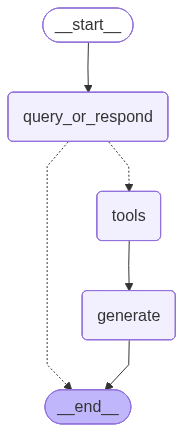

In [20]:
# Build graph
graph_builder = StateGraph(MessagesState)

graph_builder.add_node(query_or_respond)
graph_builder.add_node(tools)
graph_builder.add_node(generate)

graph_builder.set_entry_point("query_or_respond")
graph_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,
        {END: END, 
        "tools": "tools"},
)
graph_builder.add_edge("tools", "generate")
graph_builder.add_edge("generate", END)

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
graph

In [21]:
# Specify an ID for the thread
config = {"configurable": {"thread_id": "abc123"}}

In [22]:
input_message="Hello"
for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()
    

================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hello! How can I help you today?


In [ ]:
"""No, `stream_mode="values"` is not token-level streaming. It's **node-level streaming** — it yields the full state after each node completes.

So for each step in the graph it prints the last message:
- After `query_or_respond` → prints the AI message (with tool call)
- After `tools` → prints the ToolMessage (retrieved docs)
- After `generate` → prints the final AI answer

It's useful for **debugging and visibility** — you can see what each node produced step by step, rather than just getting the final answer at the end.

If you just wanted the final answer you could use `graph.invoke()` instead, which waits for the whole graph to finish and returns the final state only. `stream` here is more about observing the intermediate steps of the graph, not about streaming individual tokens.
"""
input_message = "What is Task Decomposition?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is Task Decomposition?
================================== Ai Message ==================================

Task decomposition is the process of breaking a complex goal or problem into smaller, manageable subtasks that can be planned, executed, and measured more easily. It’s used in project management, software engineering, AI/ML, operations, and everyday problem-solving.

Why it’s useful
- Clarity: Makes scope, responsibilities, and deliverables concrete.
- Estimation: Improves time/cost estimates.
- Parallelism: Lets different people or systems work simultaneously.
- Risk reduction: Surfaces dependencies and bottlenecks early.
- Reuse: Common subtasks or components can be reused.

Common approaches and contexts
- Project management: Work Breakdown Structure (WBS), Gantt tasks, Kanban boards.
- Human factors: Hierarchical Task Analysis (HTA).
- Computer science: Divide-and-conquer algorithms.
- AI plan

In [21]:
### Conversation History
chat_history=graph.get_state(config).values["messages"]
for message in chat_history:
    message.pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hi there! How can I help you today?
================================ Human Message =================================

What is Task Decomposition?
================================== Ai Message ==================================

Task decomposition is the process of breaking a complex goal or problem into smaller, manageable subtasks that can be planned, executed, and measured more easily. It’s used in project management, software engineering, AI/ML, operations, and everyday problem-solving.

Why it’s useful
- Clarity: Makes scope, responsibilities, and deliverables concrete.
- Estimation: Improves time/cost estimates.
- Parallelism: Lets different people or systems work simultaneously.
- Risk reduction: Surfaces dependencies and bottlenecks early.
- Reuse: Common subtasks or components can be reused.

Common approaches 

### ReAct Agent Architecture-Persistant Memory

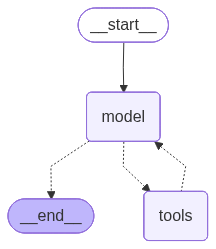

In [ ]:
"""
if agent_executor already handles its own internal tool-calling loop (which agents typically do), 
you may not even need query_or_respond and generate as separate nodes at all. 
The agent could be the only node since it handles the 
full cycle of reasoning → tool calling → generating a response internally. But that depends on how your agent is set up."""

from langchain.agents import create_agent
memory = MemorySaver()
agent_executor=create_agent(llm,[retrieve],checkpointer=memory)
agent_executor

In [25]:
config = {"configurable": {"thread_id": "def234"}}

input_message = (
    "What is the standard method for Task Decomposition?\n\n"
    "Once you get the answer, look up common extensions of that method."
)

for event in agent_executor.stream({"messages": [{"role": "user", "content": input_message}]},
                                   stream_mode="values",
                                   config=config):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What is the standard method for Task Decomposition?

Once you get the answer, look up common extensions of that method.
================================== Ai Message ==================================
Tool Calls:
  retrieve (call_NLqPT2nhbzIRduNyBNuApxyL)
 Call ID: call_NLqPT2nhbzIRduNyBNuApxyL
  Args:
    query: What is the standard method for Task Decomposition? 'standard method' task decomposition ergonomics HCI 'Hierarchical Task Analysis'
================================= Tool Message =================================
Name: retrieve

('Source: {\'source\': \'https://lilianweng.github.io/posts/2023-06-23-agent/\'}\nContent: Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#\nChain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. T